In [3]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sys
import os

In [2]:


# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().dropna() # load data from files

In [47]:


X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]].dropna()

scale = StandardScaler()
scaled_X = scale.fit_transform(X)
y = (df["AD"]).dropna()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 42)


In [6]:
models = {
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

Lasso:
  RMSE: 7.1810
  R^2:  0.3541
  Coefficients: {'Area': np.float64(0.14461817270349137), 'Circumference': np.float64(0.7766648705024779), 'CoA': np.float64(-0.0), 'MU': np.float64(-0.5459243784895738), 'Span': np.float64(-3.7749878187694703), 'MCS': np.float64(4.245565552537479)}
----------------------------------------


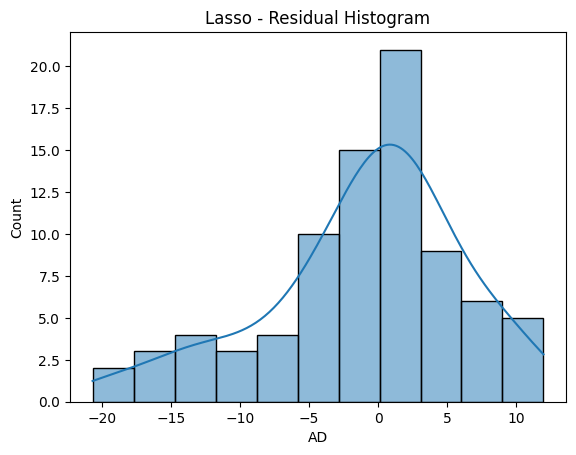

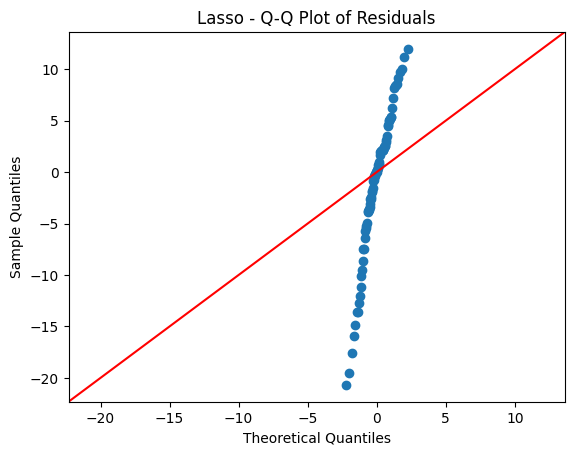

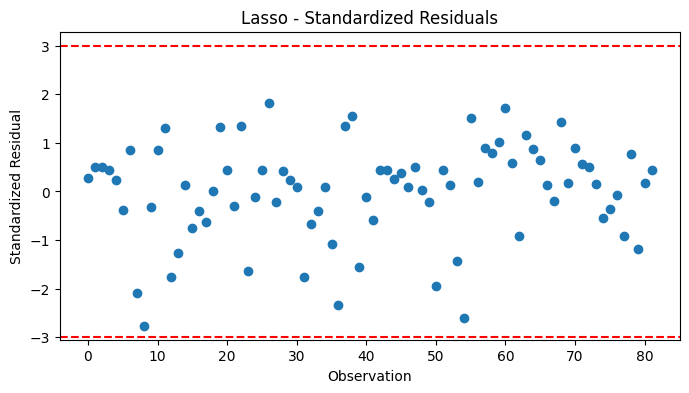

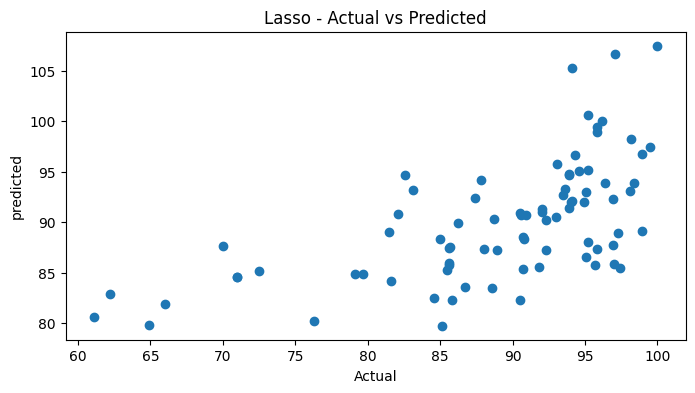

Ridge:
  RMSE: 7.0913
  R^2:  0.3701
  Coefficients: {'Area': np.float64(2.0966774077488153), 'Circumference': np.float64(0.6197936734077447), 'CoA': np.float64(-1.6456627175655254), 'MU': np.float64(-0.7721893015424619), 'Span': np.float64(-4.581626239626344), 'MCS': np.float64(4.641913613175676)}
----------------------------------------


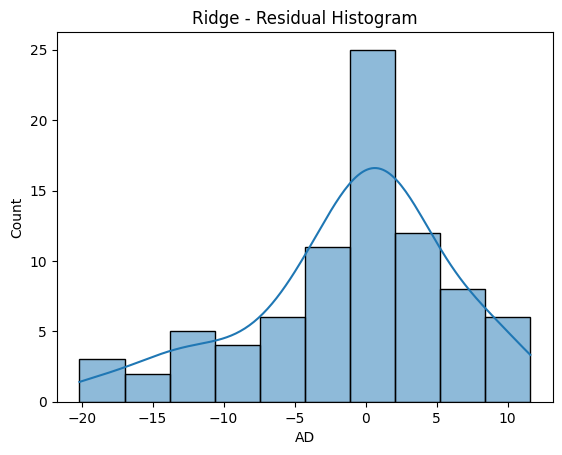

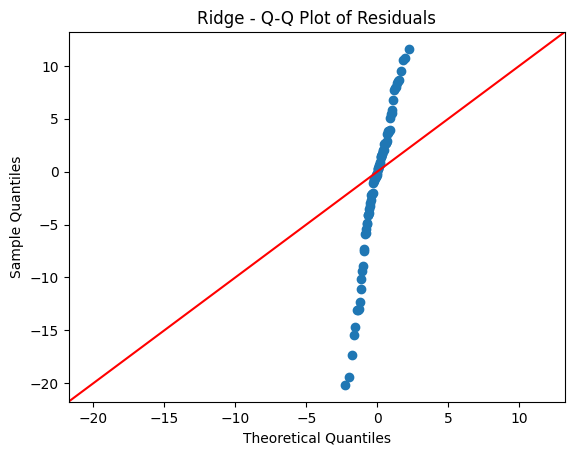

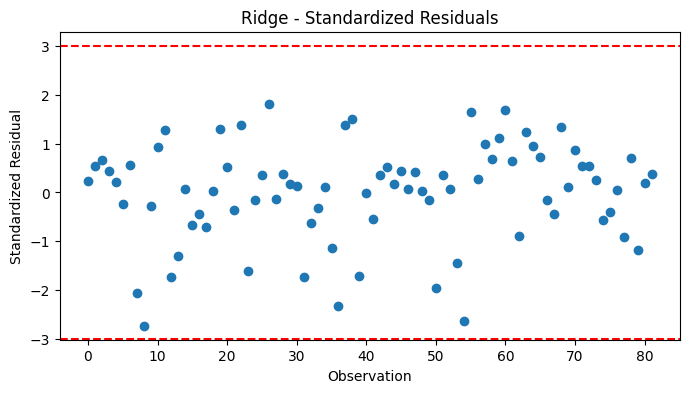

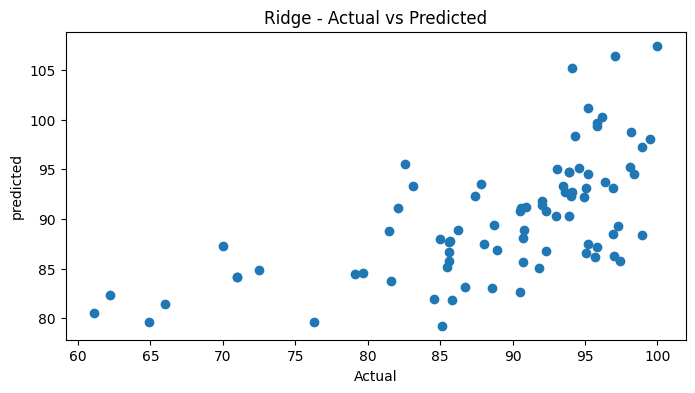

ElasticNet:
  RMSE: 7.2132
  R^2:  0.3483
  Coefficients: {'Area': np.float64(0.37871033094310375), 'Circumference': np.float64(0.32716068828009703), 'CoA': np.float64(-0.07515550980501015), 'MU': np.float64(-0.5992301027198133), 'Span': np.float64(-3.4106835398520134), 'MCS': np.float64(4.05239304081155)}
----------------------------------------


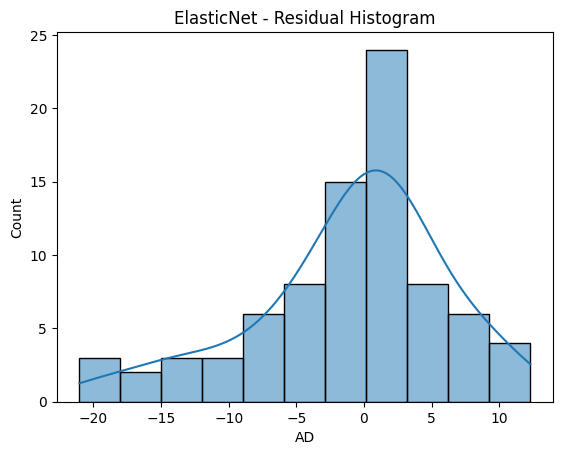

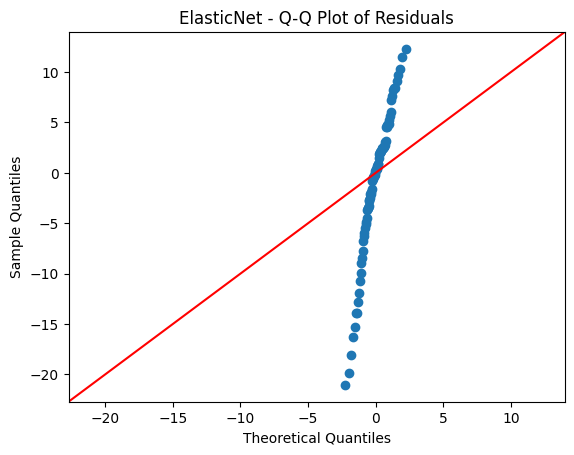

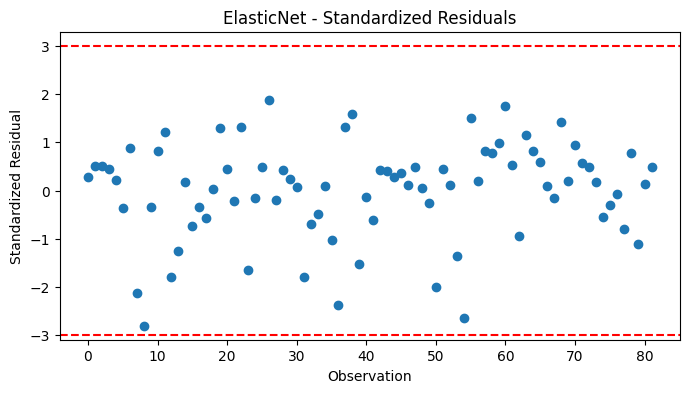

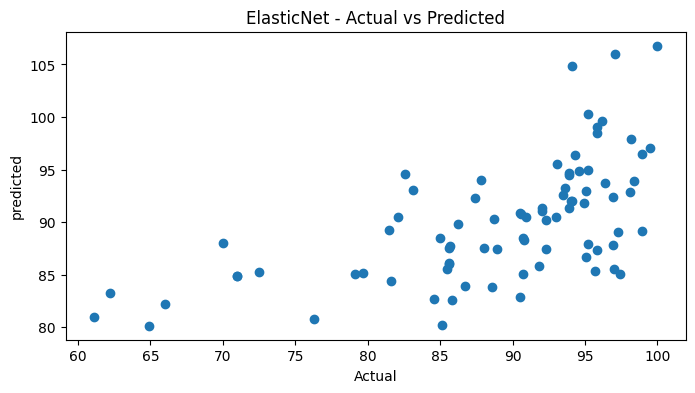

In [7]:


results = {}
import numpy as np
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    fitted = y_pred
    standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
    results[name] = {
        "RMSE": mean_squared_error(y_test, y_pred)**0.5,
        "R2": r2_score(y_test, y_pred),
        "Coefficients": model.coef_
    }
    print(f"{name}:")
    print(f"  RMSE: {results[name]['RMSE']:.4f}")
    print(f"  R^2:  {results[name]['R2']:.4f}")
    print(f"  Coefficients: {dict(zip(X.columns, model.coef_))}")
    print("-" * 40)
    # Histogram
    sns.histplot(residuals, kde=True)
    plt.title(f"{name} - Residual Histogram")
    plt.show()

# Q-Q Plot
    import statsmodels.api as sm
    sm.qqplot(residuals, line='45')
    plt.title(f"{name} - Q-Q Plot of Residuals")
    plt.show()


    
    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(standardized_residuals)), standardized_residuals)
    plt.axhline(3, color='red', linestyle='--')
    plt.axhline(-3, color='red', linestyle='--')
    plt.title(f"{name} - Standardized Residuals")
    plt.xlabel("Observation")
    plt.ylabel("Standardized Residual")
    plt.show()


    plt.figure(figsize=(8, 4))
    plt.scatter(y_test, y_pred)
   
    plt.title(f"{name} - Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("predicted")
    plt.show()




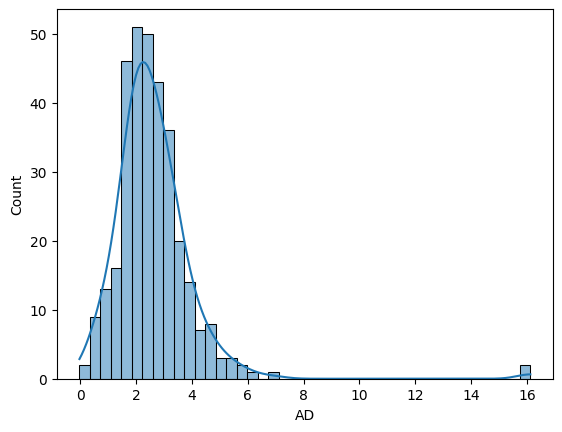

In [58]:
sns.histplot(y_logit, kde=True)

plt.show()

All of these models show the fact that the assumptions are not statisfied , and also many of the predicted values fall outside of the range (0,100). Hence we need either transforamtion or a diffrent method in order to address this.

### Transformation (logit)

In [28]:
## Transformation (logit)
def logit_transform(x): 
    x = np.clip(x, 1e-5, 100 - 1e-5) 
    print(x) # Avoid division by zero or log(0)
    return np.log(x / (100 - x))    

def inverse_logit(y_prime):
    return 100 * np.exp(y_prime) / (1 + np.exp(y_prime))


In [ ]:
# import math
# from math import log


# x = np.clip(y,0, 100 - 1e-5)
# #print(min(x))
# #print(min(y))
# print(log(49.4/(100-49.4)))
# y_logit = np.log(x / (100 - x))

49.4
-0.024001152099543125


In [49]:
#max(y_logit)
min(y_logit)

-0.024001152099543125

In [59]:
X_train, X_test, y_train_logit, y_test_logit = train_test_split(scaled_X, y_logit, test_size=0.25, random_state=42)


Lasso:
  RMSE: 7.7924
  R^2 : 0.2394
  Coefficients: {'Area': np.float64(-0.0), 'Circumference': np.float64(-0.0), 'CoA': np.float64(-0.0), 'MU': np.float64(-0.0), 'Span': np.float64(-0.22583343856292062), 'MCS': np.float64(0.6411118509067922)}
----------------------------------------


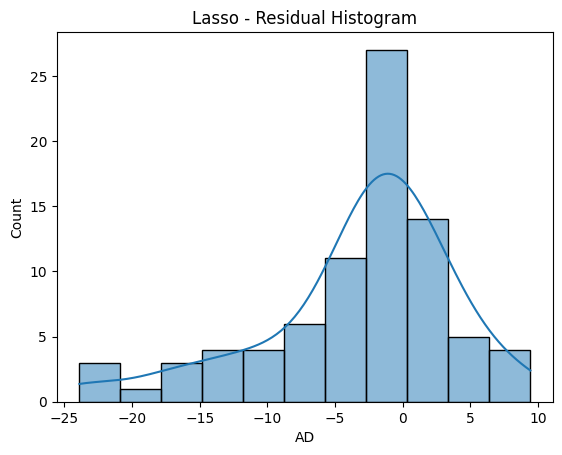

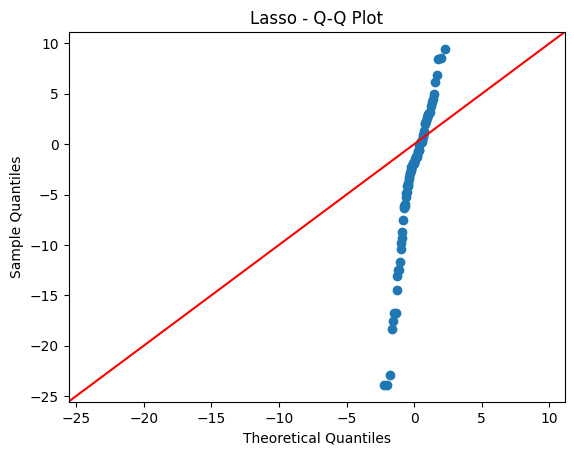

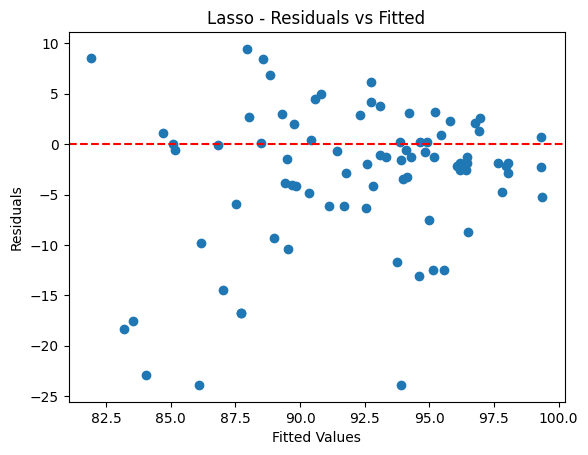

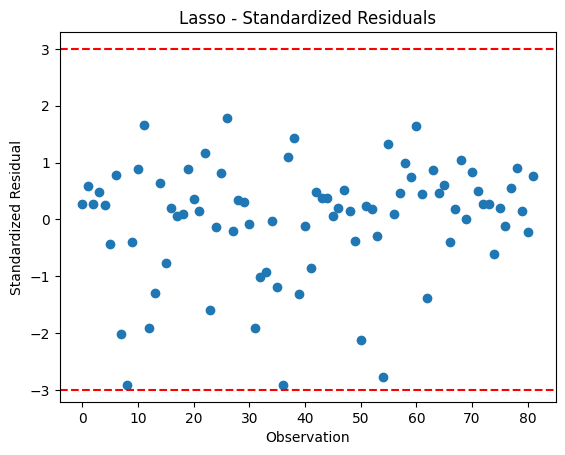

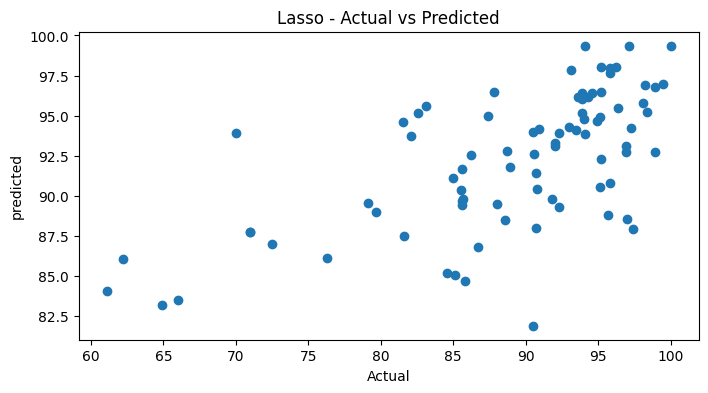

Ridge:
  RMSE: 7.0572
  R^2 : 0.3762
  Coefficients: {'Area': np.float64(-0.08043983512281773), 'Circumference': np.float64(0.19910329919965708), 'CoA': np.float64(-0.031467743365640524), 'MU': np.float64(-0.020914197095697386), 'Span': np.float64(-0.44292609861779747), 'MCS': np.float64(0.7838868013232794)}
----------------------------------------


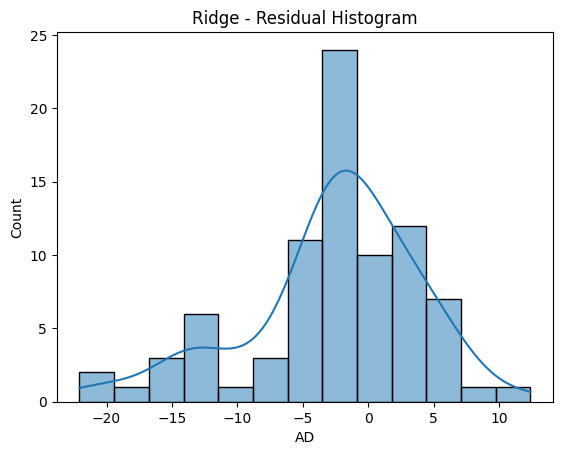

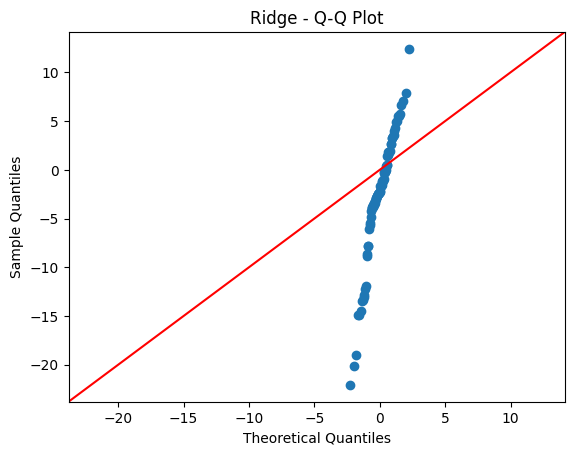

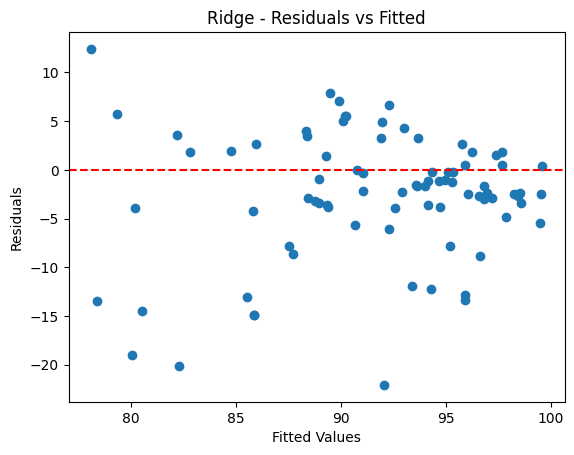

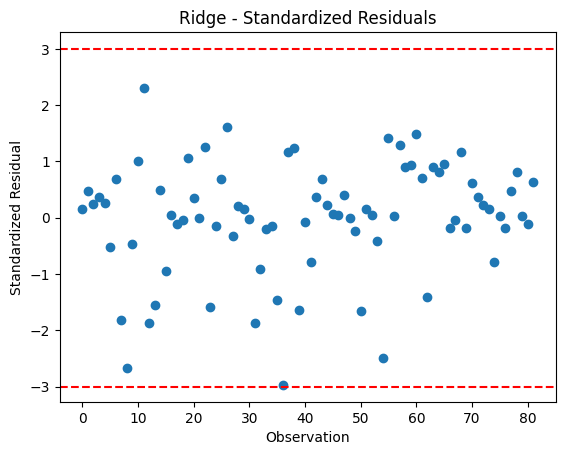

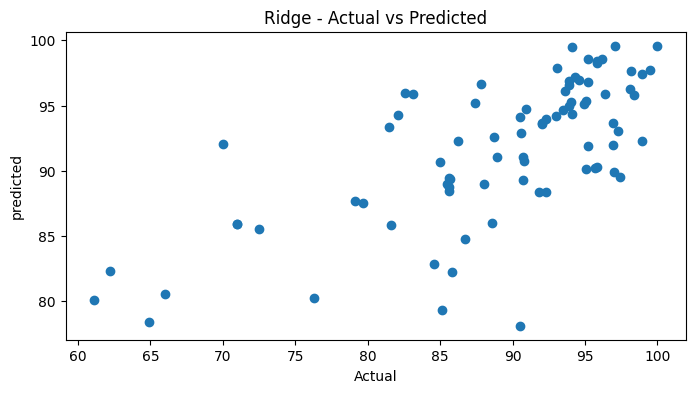

ElasticNet:
  RMSE: 7.6172
  R^2 : 0.2733
  Coefficients: {'Area': np.float64(-0.0), 'Circumference': np.float64(-0.0), 'CoA': np.float64(0.0), 'MU': np.float64(-0.0), 'Span': np.float64(-0.2645569025512779), 'MCS': np.float64(0.6587206584725958)}
----------------------------------------


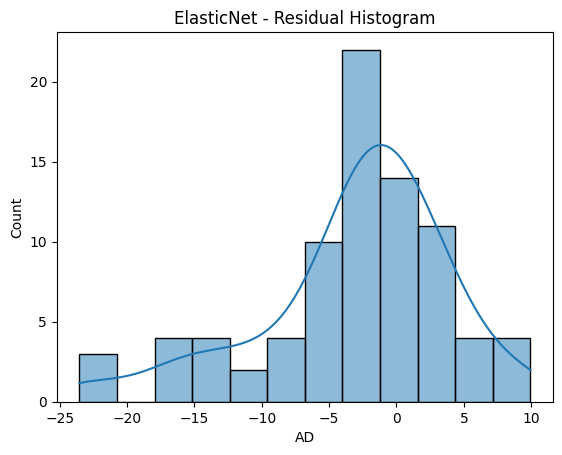

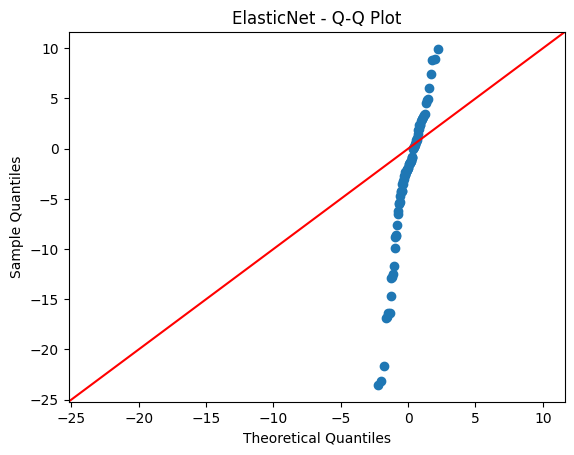

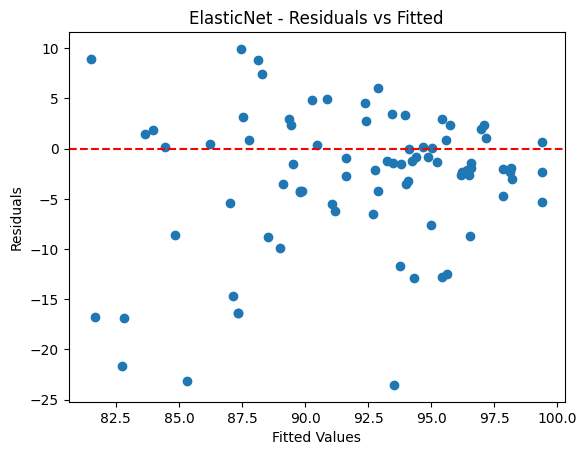

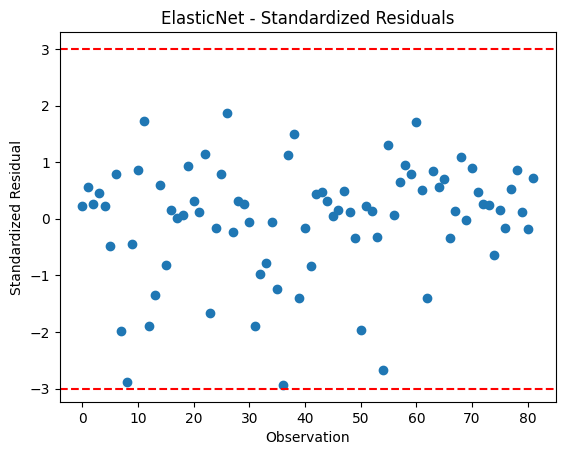

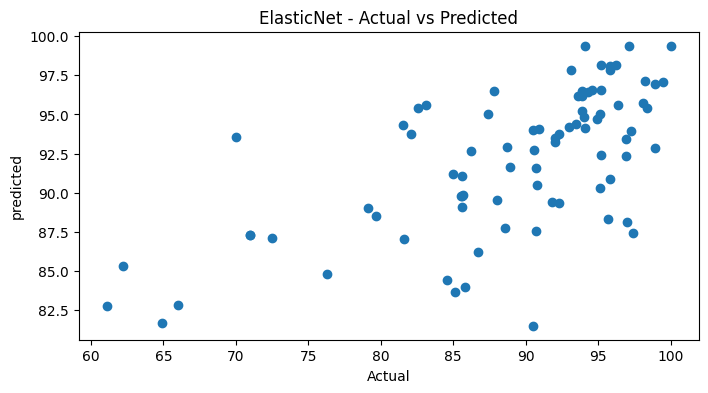

In [60]:
models = {
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train_logit)
    
    # Predict in logit scale, then inverse transform
    y_pred_logit = model.predict(X_test)
    y_pred = inverse_logit(y_pred_logit)
    y_true = inverse_logit(y_test_logit)  # actuals in original scale

    # Residuals for diagnostics
    residuals = y_true - y_pred
    fitted = y_pred

    # Store results
    results[name] = {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "Coefficients": model.coef_
    }

    # Print results
    print(f"{name}:")
    print(f"  RMSE: {results[name]['RMSE']:.4f}")
    print(f"  R^2 : {results[name]['R2']:.4f}")
    print(f"  Coefficients: {dict(zip(X.columns, model.coef_))}")
    print("-" * 40)

    # Diagnostic Plots
    # 1. Residual Histogram
    sns.histplot(residuals, kde=True)
    plt.title(f"{name} - Residual Histogram")
    plt.show()

    # 2. Q-Q Plot
    import statsmodels.api as sm
    sm.qqplot(residuals, line='45')
    plt.title(f"{name} - Q-Q Plot")
    plt.show()

    # 3. Residuals vs Fitted
    plt.scatter(fitted, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(f"{name} - Residuals vs Fitted")
    plt.show()

    # 4. Standardized Residuals
    std_resid = (residuals - np.mean(residuals)) / np.std(residuals)
    plt.scatter(range(len(std_resid)), std_resid)
    plt.axhline(3, color='red', linestyle='--')
    plt.axhline(-3, color='red', linestyle='--')
    plt.title(f"{name} - Standardized Residuals")
    plt.xlabel("Observation")
    plt.ylabel("Standardized Residual")
    plt.show()


    
    plt.figure(figsize=(8, 4))
    plt.scatter(y_test, y_pred)
   
    plt.title(f"{name} - Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("predicted")
    plt.show()